In [1]:
library(tidyverse)
library(lme4)
library(lmerTest)
library(emmeans)
library(broom.mixed)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack



Attaching package: 'lmerTest'


The following object is masked from 'package:lme4':

    lmer


The following object is masked from 'package:stats':

    step


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



In [109]:
# --------------------------------------------------
# Load cagemate-only hierarchy dataframe
# --------------------------------------------------

df <- read_csv(
    
    "C:/Users/sjs93/OneDrive/Documents/GitHub/diff_fam_social_memory_ephys/other_peoples_sutff/sequioa/Phase1_hab_dis_rank_GLM/lfp_kinematics_habit_dishabit_cagemate_rank.csv"
)

# inspect dataframe
glimpse(df)

table(df$condition)

Rows: 148050 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): recording, event, partner, condition, band, metric, region_or_pair...
dbl (19): Unnamed: 0, subject, trial, event_length, distance, velocity_mouse...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 148,050
Columns: 27
$ `Unnamed: 0`             <dbl> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,…
$ subject                  <dbl> 1.1, 1.1, 1.1, 1.1, 1.1, 1.1, 1.1, 1.1, 1.1, …
$ recording                <chr> "11_cage_p1_merged.rec", "11_cage_p1_merged.r…
$ event                    <chr> "exp1 sniff", "exp1 sniff", "exp1 sniff", "ex…
$ partner                  <chr> "A", "A", "A", "A", "A", "A", "A", "A", "A", …
$ trial                    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ condition                <chr> "cagemate", "cagemate", "cagemate", "cagemate…
$ event_length             <dbl> 3656, 3656, 3656, 3656, 3656, 3656, 3656, 365…
$ distance                 <dbl> 275.7197, 275.7197, 275.7197, 275.7197, 275.7…
$ velocity_mouse1          <dbl> 0.2805405, 0.2805405, 0.2805405, 0.2805405, 0…
$ velocity_mouse2          <dbl> 0.225348, 0.225348, 0.225348, 0.225348, 0.225…
$ moving_angle_mouse1      <dbl> -6.406927, -6.406927, -6.406927, -6.406927, -…
$ moving_angle


cagemate 
  148050 

In [170]:
table(emm_df$relative_rank)


higher_than_subject  lower_than_subject 
                  5                   5 

In [171]:
table(coh_df$relative_rank)


higher_than_subject  lower_than_subject 
              21600               19150 

In [172]:
# --------------------------------------------------
# Get all unique region pairs
# --------------------------------------------------

region_pairs <- unique(
    coh_df$region_or_pair
)

region_pairs

[1] "mPFC_NAc"  "mPFC_MD"   "mPFC_BLA"  "mPFC_vHPC" "NAc_MD"    "NAc_BLA"  
 [7] "NAc_vHPC"  "MD_BLA"    "MD_vHPC"   "BLA_vHPC"

In [173]:
table(
    coh_df$condition,
    coh_df$relative_rank,
    useNA = "ifany"
)

          
           higher_than_subject lower_than_subject
  cagemate               21600              19150

In [175]:
# --------------------------------------------------
# Run mixed-effects models across all region pairs
#
# This analysis tests whether normalized coherence
# differs between interactions with:
#
# - higher-ranked partners
# - lower-ranked partners
#
# across oscillatory frequency bands.
#
# Fixed effects:
# - relative_rank
# - band
# - relative_rank × band
#
# Covariates:
# - velocity_mouse1
# - event_length
#
# Random effect:
# - recording session
#
# Model:
#
# value ~ relative_rank * band +
#         velocity_mouse1 +
#         event_length +
#         (1 | recording)
#
# Analyses are performed separately for each
# coherence pair (e.g., mPFC_MD, NAc_MD, MD_BLA).
# --------------------------------------------------

# get all unique coherence region pairs
region_pairs <- unique(
    coh_df$region_or_pair
)

# initialize empty list to store ANOVA tables
results_list <- list()

# loop through each region pair
for (pair in region_pairs) {

    cat("\n=========================\n")
    cat("Running:", pair, "\n")
    cat("=========================\n")

    # subset dataframe for one region pair
    test_df <- coh_df |>
        
        filter(region_or_pair == pair)

    # fit mixed-effects model
    mixed_model <- lmer(
        
        value ~
            relative_rank * band +
            velocity_mouse1 +
            event_length +
            (1 | recording),

        data = test_df
    )

    # compute Type III ANOVA table
    model_anova <- anova(mixed_model)

    # store ANOVA results
    results_list[[pair]] <- model_anova

    # print ANOVA table to console
    print(model_anova)
}


Running: mPFC_NAc 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                   Sum Sq Mean Sq NumDF  DenDF F value  Pr(>F)    
relative_rank         586   586.0     1   85.1  2.8868 0.09296 .  
band                32137  8034.1     4 3475.0 39.5779 < 2e-16 ***
velocity_mouse1       189   189.0     1 3260.9  0.9313 0.33460    
event_length            4     4.2     1 3481.9  0.0209 0.88503    
relative_rank:band   2207   551.9     4 3475.0  2.7186 0.02818 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: mPFC_MD 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank        664.8  664.80     1   35.7  2.4769    0.1243    
band               11834.4 2958.60     4 3344.2 11.0234 6.998e-09 ***
velocity_mouse1      124.1  124.08     1 2290.3  0.4623    0.4966    
event_length         549.0  549.02     1 3344.2  2.0456    0.1527    
relative_rank:band 10756.9 2689.23     4 3344.2 10.0198 4.643e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: mPFC_BLA 


...

Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank       1202.2  1202.2     1  393.7  6.2817   0.01260 *  
band               19624.6  4906.1     4 3405.2 25.6363 < 2.2e-16 ***
velocity_mouse1      325.5   325.5     1 3392.1  1.7009   0.19226    
event_length         877.0   877.0     1 3412.4  4.5826   0.03237 *  
relative_rank:band  9060.7  2265.2     4 3405.2 11.8364 1.501e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: MD_vHPC 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                   Sum Sq Mean Sq NumDF   DenDF F value    Pr(>F)    
relative_rank      1394.1 1394.09     1  121.22  4.9530   0.02789 *  
band               6894.8 1723.70     4 2702.08  6.1241 6.656e-05 ***
velocity_mouse1     121.3  121.30     1 2705.79  0.4310   0.51157    
event_length        155.9  155.93     1 2704.18  0.5540   0.45676    
relative_rank:band 4975.2 1243.81     4 2702.08  4.4191   0.00146 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: BLA_vHPC 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                   Sum Sq Mean Sq NumDF   DenDF F value    Pr(>F)    
relative_rank      1501.2  1501.2     1    8.07  5.3058 0.0499197 *  
band               7076.6  1769.1     4 2428.87  6.2526 5.287e-05 ***
velocity_mouse1    3730.0  3730.0     1 1477.15 13.1828 0.0002922 ***
event_length        202.4   202.4     1 2424.68  0.7155 0.3977040    
relative_rank:band 4367.9  1092.0     4 2428.87  3.8593 0.0039486 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [183]:
# --------------------------------------------------
# Extract rank and rank × band p-values
# across all region pairs
# --------------------------------------------------

summary_df <- tibble()

for (pair in names(results_list)) {

    anova_table <- results_list[[pair]]

    # main effect of rank
    rank_p <- anova_table[
        "relative_rank",
        "Pr(>F)"
    ]

    # rank × frequency interaction
    interaction_p <- anova_table[
        "relative_rank:band",
        "Pr(>F)"
    ]

    summary_df <- bind_rows(

        summary_df,

        tibble(
            region_pair = pair,
            relative_rank_pvalue = rank_p,
            interaction_pvalue = interaction_p
        )
    )
}

summary_df

region_pair,relative_rank_pvalue,interaction_pvalue
<chr>,<dbl>,<dbl>
mPFC_NAc,0.0929635312,2.817571e-02
mPFC_MD,0.1243456111,4.642888e-08
mPFC_BLA,0.0850226400,1.501089e-14
mPFC_vHPC,0.3458561129,8.128881e-11
NAc_MD,0.0009035487,4.408332e-04
NAc_BLA,0.3341663352,1.081961e-06
NAc_vHPC,0.3118393035,1.032395e-03
MD_BLA,0.0126012455,1.500815e-09
MD_vHPC,0.0278942189,1.460493e-03


In [190]:
# --------------------------------------------------
# Create summary table of significant rank effects
#
# For each coherence circuit, we previously fit:
#
# value ~ relative_rank * band +
#         velocity_mouse1 +
#         event_length +
#         (1 | recording)
#
# This table summarizes:
#
# 1. Main effect of relative rank
#    (dominant vs subordinate partner)
#
# 2. Rank × frequency-band interaction
#    (whether rank effects depend on
#     oscillatory frequency)
#
# Only circuits with significant
# rank effects (p < 0.05) are retained.
#
# This table is intended for slides and
# figure planning to identify circuits
# most strongly influenced by social rank.
# --------------------------------------------------


slide_table <- summary_df |>

    filter(interaction_pvalue < 0.05) |>

    arrange(interaction_pvalue) |>

    mutate(

        Rank_p =
            ifelse(
                relative_rank_pvalue < 0.001,
                "< 0.001",
                sprintf("%.3f", relative_rank_pvalue)
            ),

        Rank_Band_p =
            ifelse(
                interaction_pvalue < 0.001,
                "< 0.001",
                sprintf("%.3f", interaction_pvalue)
            )
    ) |>

    select(
        Region_Pair = region_pair,
        Rank_p,
        Rank_Band_p
    )

slide_table

Region_Pair,Rank_p,Rank_Band_p
<chr>,<chr>,<chr>
mPFC_BLA,0.085,< 0.001
mPFC_vHPC,0.346,< 0.001
MD_BLA,0.013,< 0.001
mPFC_MD,0.124,< 0.001
NAc_BLA,0.334,< 0.001
NAc_MD,< 0.001,< 0.001
NAc_vHPC,0.312,0.001
MD_vHPC,0.028,0.001
BLA_vHPC,0.050,0.004


In [192]:
# --------------------------------------------------
# Keep only MD_BLA coherence rows
#
# We are now focusing on a single circuit for
# detailed follow-up analysis.
# --------------------------------------------------

test_df <- coh_df |>
    
    filter(region_or_pair == "MD_BLA")

In [193]:
# inspect hierarchy-condition counts

table(test_df$relative_rank)

# inspect frequency-band counts

table(test_df$band)


higher_than_subject  lower_than_subject 
               2160                1915 


      Beta      Delta High gamma  Low gamma      Theta 
       815        815        815        815        815 

In [194]:
# --------------------------------------------------
# Fit mixed-effects model
#
# Tests whether MD_BLA coherence differs
# depending on:
# - hierarchy relationship
# - oscillatory frequency band
# - their interaction
#
# while controlling for:
# - movement velocity
# - sniff duration
#
# and accounting for repeated samples
# within recording sessions.
# --------------------------------------------------

model <- lmer(
    
    value ~
        relative_rank * band +
        velocity_mouse1 +
        event_length +
        (1 | recording),

    data = test_df
)

Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


In [195]:
# --------------------------------------------------
# View Type III ANOVA table
# --------------------------------------------------

anova(model)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
relative_rank,1202.1666,1202.1666,1,393.6545,6.281741,1.260125e-02
band,19624.5691,4906.1423,4,3405.1625,25.636310,5.846928e-21
velocity_mouse1,325.5080,325.5080,1,3392.1318,1.700893,1.922597e-01
event_length,876.9853,876.9853,1,3412.4478,4.582555,3.236969e-02
relative_rank:band,9060.7435,2265.1859,4,3405.1625,11.836389,1.500815e-09


In [196]:
# --------------------------------------------------
# Compute estimated marginal means (EMMs)
#
# Estimates model-predicted coherence values
# for each hierarchy condition within each
# frequency band.
# --------------------------------------------------

emm <- emmeans(
    
    model,
    
    ~ relative_rank | band
)

emm

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3425' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3425)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3425' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3425)' or larger];
but be warned that this may result in large computation time and memory use.



band = Beta:
 relative_rank        emmean   SE  df asymp.LCL asymp.UCL
 higher_than_subject  -9.035 1.85 Inf    -12.67    -5.403
 lower_than_subject   -3.670 1.81 Inf     -7.22    -0.121

band = Delta:
 relative_rank        emmean   SE  df asymp.LCL asymp.UCL
 higher_than_subject  -0.874 1.85 Inf     -4.51     2.758
 lower_than_subject   -3.155 1.81 Inf     -6.70     0.393

band = High gamma:
 relative_rank        emmean   SE  df asymp.LCL asymp.UCL
 higher_than_subject -11.730 1.85 Inf    -15.36    -8.098
 lower_than_subject   -5.379 1.81 Inf     -8.93    -1.830

band = Low gamma:
 relative_rank        emmean   SE  df asymp.LCL asymp.UCL
 higher_than_subject  -9.459 1.85 Inf    -13.09    -5.827
 lower_than_subject   -4.160 1.81 Inf     -7.71    -0.612

band = Theta:
 relative_rank        emmean   SE  df asymp.LCL asymp.UCL
 higher_than_subject  -3.868 1.85 Inf     -7.50    -0.236
 lower_than_subject   -2.694 1.81 Inf     -6.24     0.854

Degrees-of-freedom method: asymptotic 
Confiden

In [197]:
# --------------------------------------------------
# Pairwise hierarchy comparisons within each band
# --------------------------------------------------

pairs(emm)

band = Beta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -5.37 1.58 Inf  -3.387  0.0007

band = Delta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject     2.28 1.58 Inf   1.440  0.1498

band = High gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -6.35 1.58 Inf  -4.009 <0.0001

band = Low gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -5.30 1.58 Inf  -3.345  0.0008

band = Theta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -1.17 1.58 Inf  -0.741  0.4587

Degrees-of-freedom method: asymptotic 

In [198]:
# --------------------------------------------------
# Convert EMM results into dataframe for plotting
# --------------------------------------------------

emm_df <- as.data.frame(emm)

In [199]:
# inspect dataframe

head(emm_df)

,relative_rank,band,emmean,SE,df,asymp.LCL,asymp.UCL
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,higher_than_subject,Beta,-9.0352458,1.853134,Inf,-12.667322,-5.4031691
2,lower_than_subject,Beta,-3.6695145,1.810408,Inf,-7.217849,-0.1211804
3,higher_than_subject,Delta,-0.8736279,1.853134,Inf,-4.505705,2.7584488
4,lower_than_subject,Delta,-3.1553126,1.810408,Inf,-6.703647,0.3930215
5,higher_than_subject,High gamma,-11.7304138,1.853134,Inf,-15.362490,-8.0983371
6,lower_than_subject,High gamma,-5.3786508,1.810408,Inf,-8.926985,-1.8303167


In [201]:
names(emm_df)

[1] "relative_rank" "band"          "emmean"        "SE"           
[5] "df"            "asymp.LCL"     "asymp.UCL"

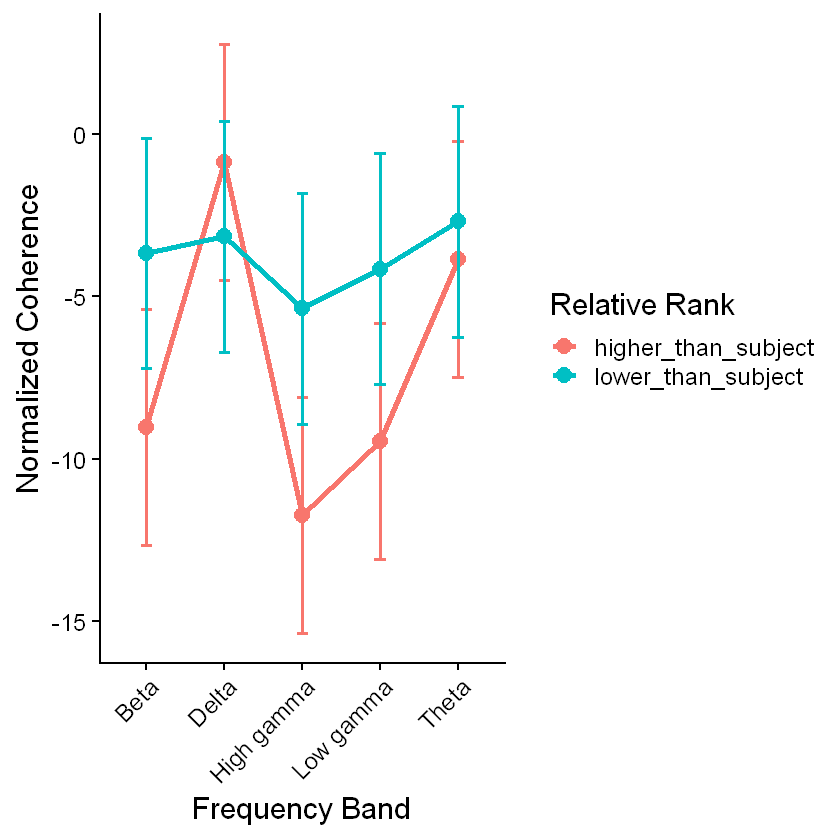

In [203]:
# --------------------------------------------------
# Plot estimated coherence by:
# - frequency band
# - hierarchy relationship
#
# Model-adjusted means from the LMM
# --------------------------------------------------

ggplot(

    emm_df,

    aes(
        x = band,
        y = emmean,
        color = relative_rank,
        group = relative_rank
    )
) +

# connect points across bands
geom_line(
    linewidth = 1.5
) +

# estimated means
geom_point(
    size = 4
) +

# confidence intervals
geom_errorbar(

    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),

    width = 0.15,
    linewidth = 1
) +

# labels
labs(

    x = "Frequency Band",

    y = "Normalized Coherence",

    color = "Relative Rank"
) +

# theme
theme_classic(
    base_size = 18
) +

theme(

    axis.text.x =
        element_text(
            angle = 45,
            hjust = 1
        )
)

In [206]:
# --------------------------------------------------
# Remove equal-rank interactions
#
# Focus analysis on:
# - higher-ranked partner interactions
# - lower-ranked partner interactions
# --------------------------------------------------

emm_df_filtered <- emm_df |>
    
    filter(
        relative_rank != "equal_rank"
    )

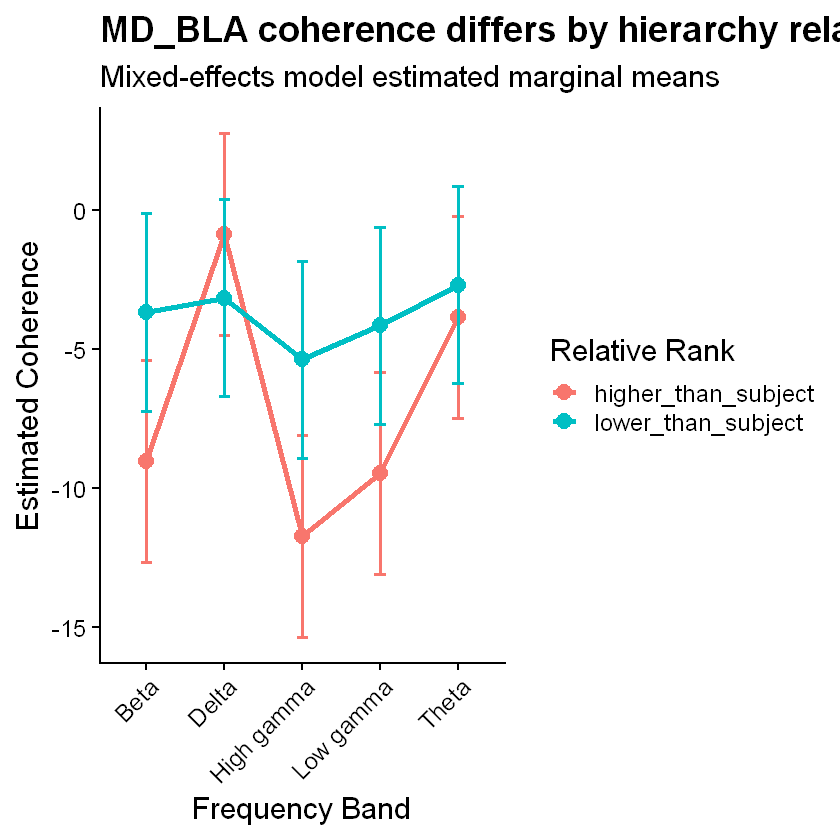

In [207]:
# --------------------------------------------------
# Plot hierarchy-dependent coherence
# after removing equal-rank interactions
# --------------------------------------------------

ggplot(
    
    emm_df_filtered,
    
    aes(
        x = band,
        y = emmean,
        color = relative_rank,
        group = relative_rank
    )
) +

# connect frequency-band estimates
geom_line(
    linewidth = 1.5
) +

# estimated marginal means
geom_point(
    size = 4
) +

# confidence intervals
geom_errorbar(
    
    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),
    
    width = 0.15,
    linewidth = 1
) +

# plot labels
labs(
    
    title =
        "MD_BLA coherence differs by hierarchy relationship",
    
    subtitle =
        "Mixed-effects model estimated marginal means",
    
    x = "Frequency Band",
    
    y = "Estimated Coherence",
    
    color = "Relative Rank"
) +

# clean plotting theme
theme_classic(
    base_size = 18
) +

theme(
    
    plot.title =
        element_text(face = "bold"),
    
    axis.text.x =
        element_text(angle = 45, hjust = 1)
)

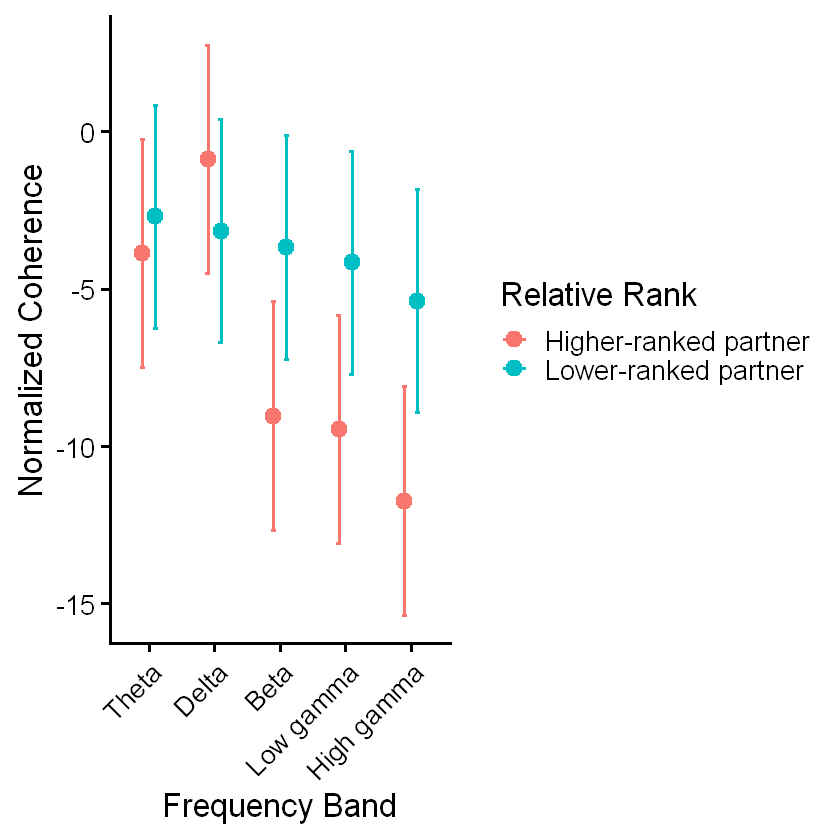

In [212]:
# --------------------------------------------------
# Plot estimated coherence by hierarchy condition
# without connecting lines
# --------------------------------------------------

ggplot(

    emm_df_filtered,

    aes(
        x = band,
        y = emmean,
        color = relative_rank
    )
) +

# estimated marginal means
geom_point(

    position =
        position_dodge(width = 0.4),

    size = 4
) +

# confidence intervals
geom_errorbar(

    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),

    position =
        position_dodge(width = 0.4),

    width = 0.15,
    linewidth = 1
) +

labs(

    x = "Frequency Band",

    y = "Normalized Coherence",

    color = "Relative Rank"
) +

theme_classic(
    base_size = 20
) +

theme(

    axis.text.x =
        element_text(
            angle = 45,
            hjust = 1
        )
)

In [213]:
# --------------------------------------------------
# Reorder frequency bands
#
# Plot frequencies from low → high
# for easier biological interpretation
# --------------------------------------------------

emm_df_filtered$band <- factor(
    
    emm_df_filtered$band,
    
    levels = c(
        "Theta",
        "Delta",
        "Beta",
        "Low gamma",
        "High gamma"
    )
)

In [214]:
# --------------------------------------------------
# Rename hierarchy labels for cleaner plotting
# --------------------------------------------------

emm_df_filtered$relative_rank <- recode(
    
    emm_df_filtered$relative_rank,
    
    "higher_than_subject" =
        "Higher-ranked partner",
    
    "lower_than_subject" =
        "Lower-ranked partner"
)

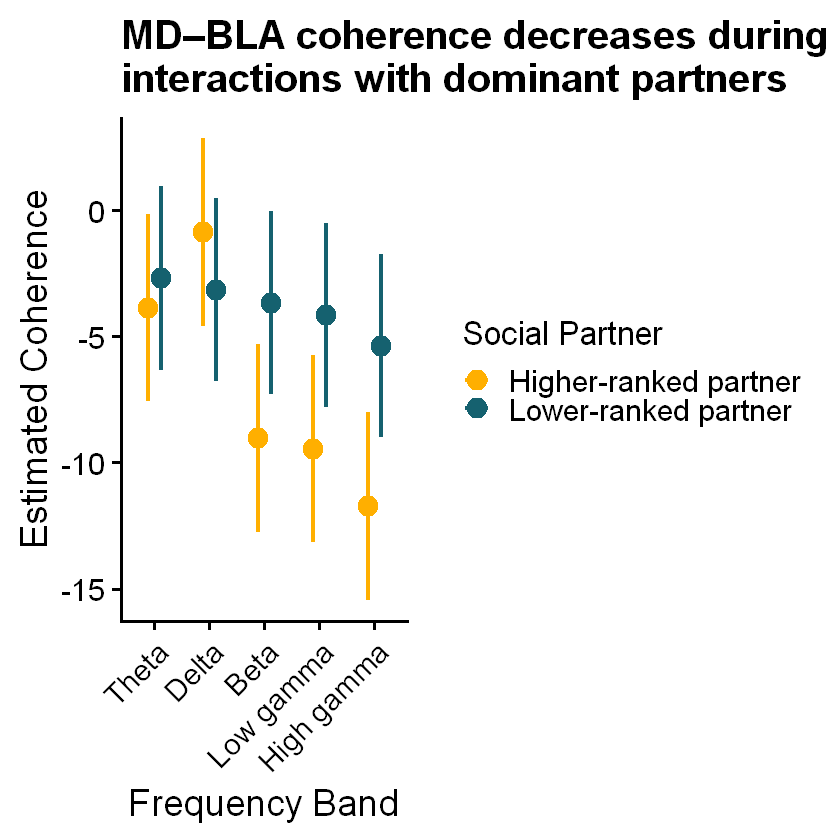

In [215]:
# --------------------------------------------------
# Plot model-estimated coherence values
#
# This visualization shows:
# - mixed-model estimated marginal means
# - confidence intervals
#
# comparing coherence during interactions with:
# - higher-ranked social partners
# - lower-ranked social partners
#
# across oscillatory frequency bands.
# --------------------------------------------------

# --------------------------------------------------
# Plot hierarchy-dependent MD_BLA coherence
# --------------------------------------------------

ggplot(
    
    emm_df_filtered,
    
    aes(
        x = band,
        y = emmean,
        color = relative_rank
    )
) +

# estimated marginal means
geom_point(
    
    position =
        position_dodge(width = 0.45),
    
    size = 5
) +

# confidence intervals
geom_errorbar(
    
    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),
    
    position =
        position_dodge(width = 0.45),
    
    width = 0.15,
    
    linewidth = 1.2
) +

# custom hierarchy colors
scale_color_manual(
    
    values = c(
        
        "Higher-ranked partner" = "#ffaf00",
        
        "Lower-ranked partner" = "#15616f"
    )
) +

# labels
labs(
    
    title =
        "MD–BLA coherence decreases during\ninteractions with dominant partners",
    
    x = "Frequency Band",
    
    y = "Estimated Coherence",
    
    color = "Social Partner"
) +

# clean theme
theme_classic(
    base_size = 22
) +

theme(
    
    # title formatting
    plot.title =
        element_text(
            face = "bold",
            size = 24
        ),
    
    # axis labels
    axis.title =
        element_text(
            size = 22
        ),
    
    # axis tick labels
    axis.text =
        element_text(
            size = 18,
            color = "black"
        ),
    
    # rotate x labels
    axis.text.x =
        element_text(
            angle = 45,
            hjust = 1
        ),
    
    # legend formatting
    legend.title =
        element_text(
            size = 20
        ),
    
    legend.text =
        element_text(
            size = 18
        ),
    
    # remove top/right borders
    panel.border =
        element_blank()
)

In [134]:
# --------------------------------------------------
# Subset NAc_MD data
# --------------------------------------------------

test_df <- coh_df |>
    
    filter(
        region_or_pair == "NAc_MD",
        relative_rank != "equal_rank"
    )

In [135]:
# --------------------------------------------------
# Keep only dominant/subordinate interactions
# --------------------------------------------------

test_df <- coh_df |>
    
    filter(
        region_or_pair == "NAc_MD",
        
        relative_rank != "equal_rank"
    )

In [136]:
# --------------------------------------------------
# Fit NAc_MD mixed model
# --------------------------------------------------

model <- lmer(
    
    value ~
        relative_rank * band +
        velocity_mouse1 +
        event_length +
        (1 | recording),

    data = test_df
)

Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


In [137]:
# --------------------------------------------------
# Type III ANOVA
# --------------------------------------------------

anova(model)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
relative_rank,1812.0053,1812.0053,1,724.8066,11.107304,9.035487e-04
band,16148.2689,4037.0672,4,3515.1054,24.746580,3.118103e-20
velocity_mouse1,424.3870,424.3870,1,3521.4582,2.601425,1.068573e-01
event_length,502.0453,502.0453,1,3521.1028,3.077458,7.947149e-02
relative_rank:band,3316.0799,829.0200,4,3515.1054,5.081761,4.408332e-04


In [138]:
# --------------------------------------------------
# Compute NEW estimated marginal means
# --------------------------------------------------

emm <- emmeans(
    
    model,
    
    ~ relative_rank | band
)

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3535' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3535)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3535' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3535)' or larger];
but be warned that this may result in large computation time and memory use.



In [139]:
# --------------------------------------------------
# Convert emmeans to dataframe
# --------------------------------------------------

emm_df <- as.data.frame(emm)

In [140]:
emm_df

,relative_rank,band,emmean,SE,df,asymp.LCL,asymp.UCL
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,higher_than_subject,Beta,-5.6488857,1.914781,Inf,-9.401788,-1.8959830
2,lower_than_subject,Beta,0.3391814,1.985182,Inf,-3.551703,4.2300658
3,higher_than_subject,Delta,0.7511133,1.914781,Inf,-3.001789,4.5040159
4,lower_than_subject,Delta,1.2811389,1.985182,Inf,-2.609745,5.1720232
5,higher_than_subject,High gamma,-8.1657501,1.914781,Inf,-11.918653,-4.4128475
6,lower_than_subject,High gamma,-2.9982806,1.985182,Inf,-6.889165,0.8926038
7,higher_than_subject,Low gamma,-5.2335079,1.914781,Inf,-8.986411,-1.4806053
8,lower_than_subject,Low gamma,-1.9329988,1.985182,Inf,-5.823883,1.9578855
9,higher_than_subject,Theta,-5.0693696,1.914781,Inf,-8.822272,-1.3164670


In [141]:
# --------------------------------------------------
# Pairwise hierarchy comparisons within each band
# --------------------------------------------------

pairs(emm)

band = Beta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -5.99 1.48 Inf  -4.058 <0.0001

band = Delta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -0.53 1.48 Inf  -0.359  0.7194

band = High gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -5.17 1.48 Inf  -3.502  0.0005

band = Low gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -3.30 1.48 Inf  -2.237  0.0253

band = Theta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -4.99 1.48 Inf  -3.380  0.0007

Degrees-of-freedom method: asymptotic 

In [142]:
# --------------------------------------------------
# Remove equal-rank interactions
#
# Focus only on:
# - higher-ranked partner interactions
# - lower-ranked partner interactions
# --------------------------------------------------

emm_df_filtered <- emm_df |>
    
    filter(
        relative_rank != "equal_rank"
    )

In [143]:
# --------------------------------------------------
# Reorder frequency bands
# --------------------------------------------------

emm_df_filtered$band <- factor(
    
    emm_df_filtered$band,
    
    levels = c(
        "Theta",
        "Delta",
        "Beta",
        "Low gamma",
        "High gamma"
    )
)

In [144]:
# --------------------------------------------------
# Rename hierarchy labels
# --------------------------------------------------

emm_df_filtered$relative_rank <- recode(
    
    emm_df_filtered$relative_rank,
    
    "higher_than_subject" =
        "Higher-ranked partner",
    
    "lower_than_subject" =
        "Lower-ranked partner"
)

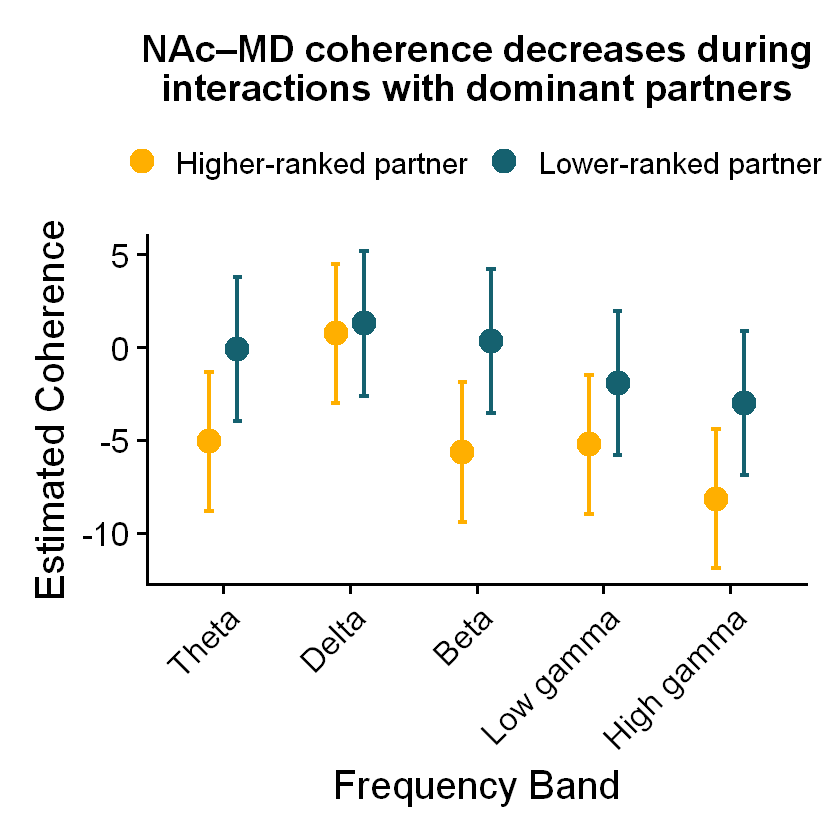

In [145]:
# --------------------------------------------------
# Create publication-style hierarchy coherence plot
# --------------------------------------------------

p <- ggplot(
    
    emm_df_filtered,
    
    aes(
        x = band,
        y = emmean,
        color = relative_rank
    )
) +

# estimated means
geom_point(
    
    position =
        position_dodge(width = 0.45),
    
    size = 6
) +

# confidence intervals
geom_errorbar(
    
    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),
    
    position =
        position_dodge(width = 0.45),
    
    width = 0.15,
    
    linewidth = 1.4
) +

# custom colors
scale_color_manual(
    
    values = c(
        
        "Higher-ranked partner" = "#ffaf00",
        
        "Lower-ranked partner" = "#15616f"
    )
) +

# labels
labs(
    
    title =
        "NAc–MD coherence decreases during\ninteractions with dominant partners",
    
    x = "Frequency Band",
    
    y = "Estimated Coherence",
    
    color = NULL
) +

# cleaner theme
theme_classic(
    base_size = 24
) +

theme(
    
    # centered title
    plot.title =
        element_text(
            face = "bold",
            size = 22,
            hjust = 0.5
        ),
    
    # axis titles
    axis.title =
        element_text(
            size = 24
        ),
    
    # tick labels
    axis.text =
        element_text(
            size = 20,
            color = "black"
        ),
    
    axis.text.x =
        element_text(
            angle = 45,
            hjust = 1
        ),
    
    # legend on top
    legend.position = "top",
    
    legend.text =
        element_text(
            size = 18
        ),
    
    # spacing
    plot.margin =
        margin(20,20,20,20)
)

p

In [146]:
# --------------------------------------------------
# Subset MD_vHPC data
# --------------------------------------------------

test_df <- coh_df |>
    
    filter(
        region_or_pair == "MD_vHPC",
        
        relative_rank != "equal_rank"
    )

In [147]:
# --------------------------------------------------
# Fit mixed model
# --------------------------------------------------

model <- lmer(
    
    value ~
        relative_rank * band +
        velocity_mouse1 +
        event_length +
        (1 | recording),

    data = test_df
)

Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


In [148]:
# --------------------------------------------------
# Type III ANOVA
# --------------------------------------------------

anova(model)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
relative_rank,1394.0905,1394.0905,1,121.2194,4.9530243,2.789422e-02
band,6894.7912,1723.6978,4,2702.0783,6.1240769,6.655709e-05
velocity_mouse1,121.2993,121.2993,1,2705.7855,0.4309607,5.115737e-01
event_length,155.9277,155.9277,1,2704.1804,0.5539912,4.567561e-01
relative_rank:band,4975.2315,1243.8079,4,2702.0783,4.4190896,1.460493e-03


In [149]:
emm <- emmeans(
    
    model,
    
    ~ relative_rank | band
)

pairs(emm)

band = Beta:
 contrast                                 estimate   SE  df t.ratio p.value
 higher_than_subject - lower_than_subject     3.71 3.57 162   1.041  0.2994

band = Delta:
 contrast                                 estimate   SE  df t.ratio p.value
 higher_than_subject - lower_than_subject    10.32 3.57 162   2.893  0.0043

band = High gamma:
 contrast                                 estimate   SE  df t.ratio p.value
 higher_than_subject - lower_than_subject     3.84 3.57 162   1.078  0.2828

band = Low gamma:
 contrast                                 estimate   SE  df t.ratio p.value
 higher_than_subject - lower_than_subject     8.70 3.57 162   2.441  0.0157

band = Theta:
 contrast                                 estimate   SE  df t.ratio p.value
 higher_than_subject - lower_than_subject     8.40 3.57 162   2.355  0.0197

Degrees-of-freedom method: kenward-roger 

In [150]:
# --------------------------------------------------
# Convert emmeans to dataframe
# --------------------------------------------------

emm_df <- as.data.frame(emm)

In [151]:
# --------------------------------------------------
# Remove equal-rank interactions
# --------------------------------------------------

emm_df_filtered <- emm_df |>

    filter(
        relative_rank != "equal_rank"
    )

In [152]:
# --------------------------------------------------
# Reorder frequency bands
# --------------------------------------------------

emm_df_filtered$band <- factor(

    emm_df_filtered$band,

    levels = c(
        "Theta",
        "Delta",
        "Beta",
        "Low gamma",
        "High gamma"
    )
)

In [153]:
# --------------------------------------------------
# Rename hierarchy labels
# --------------------------------------------------

emm_df_filtered$relative_rank <- recode(

    emm_df_filtered$relative_rank,

    "higher_than_subject" =
        "Higher-ranked partner",

    "lower_than_subject" =
        "Lower-ranked partner"
)

In [154]:
colnames(emm_df_filtered)

[1] "relative_rank" "band"          "emmean"        "SE"           
[5] "df"            "lower.CL"      "upper.CL"

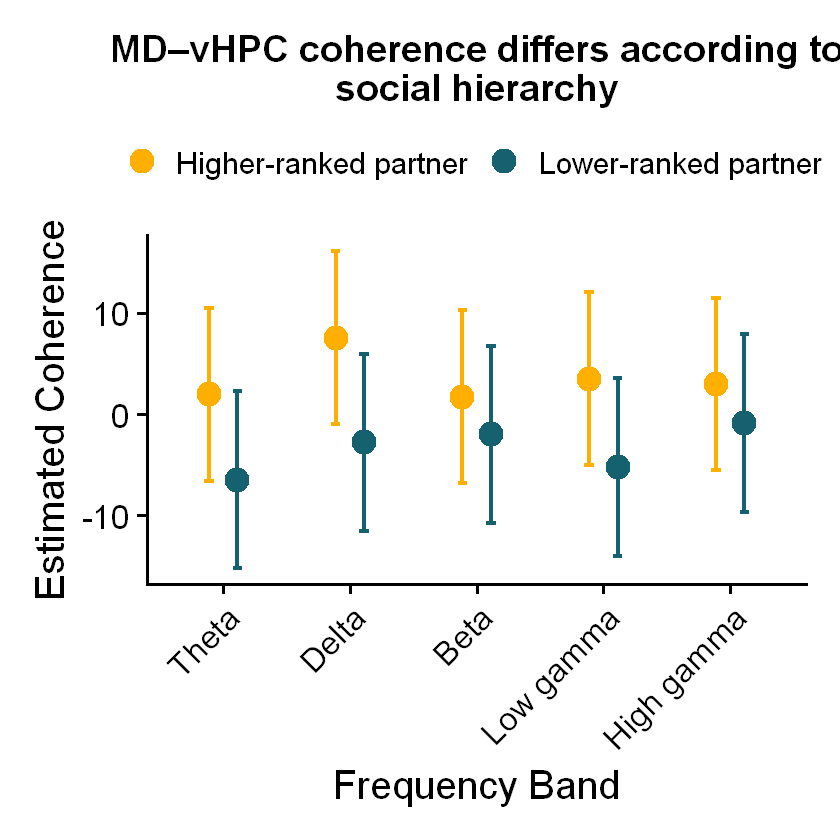

In [155]:
# --------------------------------------------------
# Create publication-style hierarchy coherence plot
# --------------------------------------------------

p <- ggplot(

    emm_df_filtered,

    aes(
        x = band,
        y = emmean,
        color = relative_rank
    )
) +

# estimated means
geom_point(

    position =
        position_dodge(width = 0.45),

    size = 6
) +

# confidence intervals
geom_errorbar(

    aes(
        ymin = lower.CL,
        ymax = upper.CL
    ),

    position =
        position_dodge(width = 0.45),

    width = 0.15,

    linewidth = 1.4
) +

# custom colors
scale_color_manual(

    values = c(

        "Higher-ranked partner" = "#ffaf00",

        "Lower-ranked partner" = "#15616f"
    )
) +

# labels
labs(

    title =
        "MD–vHPC coherence differs according to\nsocial hierarchy",

    x = "Frequency Band",

    y = "Estimated Coherence",

    color = NULL
) +

# cleaner theme
theme_classic(
    base_size = 24
) +

theme(

    plot.title =
        element_text(
            face = "bold",
            size = 22,
            hjust = 0.5
        ),

    axis.title =
        element_text(
            size = 24
        ),

    axis.text =
        element_text(
            size = 20,
            color = "black"
        ),

    axis.text.x =
        element_text(
            angle = 45,
            hjust = 1
        ),

    legend.position = "top",

    legend.text =
        element_text(
            size = 18
        ),

    plot.margin =
        margin(20,20,20,20)
)

p

In [156]:
test_df <- coh_df |>

    filter(
        region_or_pair == "mPFC_MD",
        relative_rank != "equal_rank"
    )

model <- lmer(

    value ~

        relative_rank * band +

        velocity_mouse1 +

        event_length +

        (1 | recording),

    data = test_df
)

emm <- emmeans(
    model,
    ~ relative_rank | band
)

pairs(emm)

Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3365' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3365)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3365' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3365)' or larger];
but be warned that this may result in large computation time and memory use.



band = Beta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    1.989 1.67 Inf   1.192  0.2332

band = Delta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    8.222 1.67 Inf   4.928 <0.0001

band = High gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject   -2.289 1.67 Inf  -1.372  0.1700

band = Low gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    2.393 1.67 Inf   1.434  0.1515

band = Theta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject   -0.688 1.67 Inf  -0.412  0.6800

Degrees-of-freedom method: asymptotic 

In [157]:
table(df$relative_rank, df$partner)

                     
                          A     B
  equal_rank              0  5425
  higher_than_subject 58450 17150
  lower_than_subject  56175 10850

In [158]:
table(df$partner_mouse, df$relative_rank)

     
      equal_rank higher_than_subject lower_than_subject
  1.1          0                5425               2625
  1.2          0               11900                  0
  1.3          0                   0              13475
  2.1          0               13650                  0
  2.2       3150                8400                  0
  2.3          0                   0              15750
  2.4       1400                   0              18375
  3.1          0                3500               1225
  3.2          0                   0               9800
  3.3          0               16800                  0
  4.1          0                   0               5775
  4.3        875               14175                  0
  4.4          0                1750                  0


Analyzing: mPFC 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."



ANOVA table for mPFC :
Type III Analysis of Variance Table with Satterthwaite's method
                   Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank        1062    1062     1  882.8  0.6554    0.4184    
band               246853   61713     4 3718.2 38.0682 < 2.2e-16 ***
velocity_mouse1       555     555     1 3726.5  0.3421    0.5587    
event_length          480     480     1 3721.0  0.2962    0.5863    
relative_rank:band  43053   10763     4 3718.2  6.6395 2.543e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3740' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3740)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3740' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3740)' or larger];
but be warned that this may result in large computation time and memory use.




Analyzing: MD 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."



ANOVA table for MD :
Type III Analysis of Variance Table with Satterthwaite's method
                   Sum Sq Mean Sq NumDF  DenDF  F value    Pr(>F)    
relative_rank      280201  280201     1 2303.3 127.1262 < 2.2e-16 ***
band               105656   26414     4 3678.8  11.9839 1.122e-09 ***
velocity_mouse1      1238    1238     1 3686.4   0.5618    0.4536    
event_length         9870    9870     1 3681.9   4.4779    0.0344 *  
relative_rank:band 163092   40773     4 3678.8  18.4986 4.604e-15 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3700' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3700)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3700' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3700)' or larger];
but be warned that this may result in large computation time and memory use.



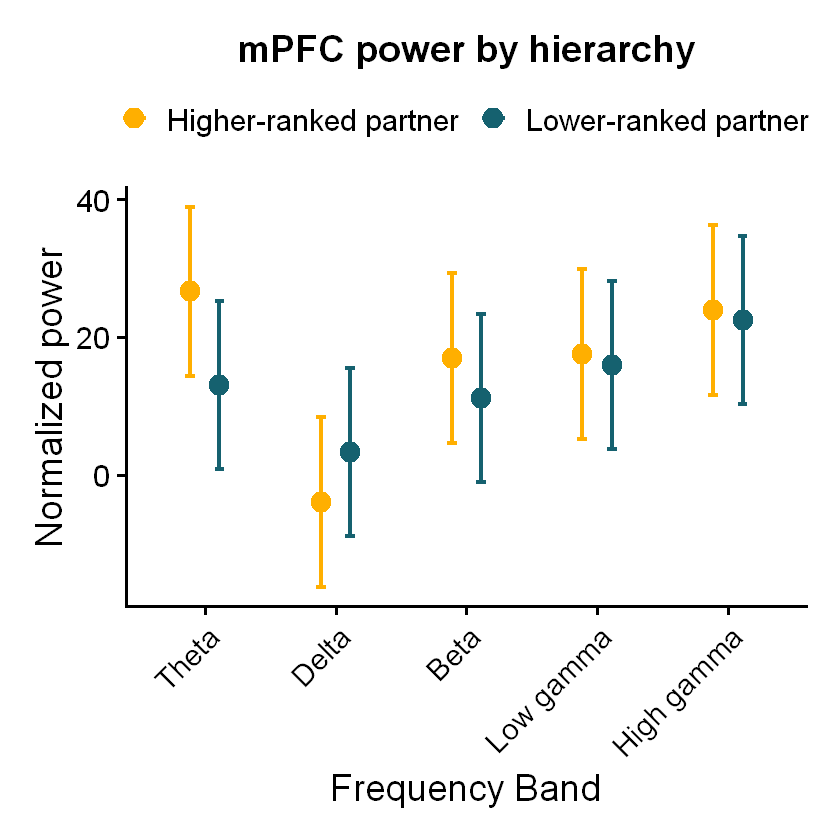


Analyzing: NAc 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."



ANOVA table for NAc :
Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF  F value    Pr(>F)    
relative_rank      1523398 1523398     1 3738.9 653.3767 < 2.2e-16 ***
band                198651   49663     4 3808.9  21.3000 < 2.2e-16 ***
velocity_mouse1       6289    6289     1 3811.0   2.6975  0.100588    
event_length          1682    1682     1 3809.3   0.7213  0.395759    
relative_rank:band   39682    9921     4 3808.9   4.2549  0.001945 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3830' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3830)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3830' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3830)' or larger];
but be warned that this may result in large computation time and memory use.



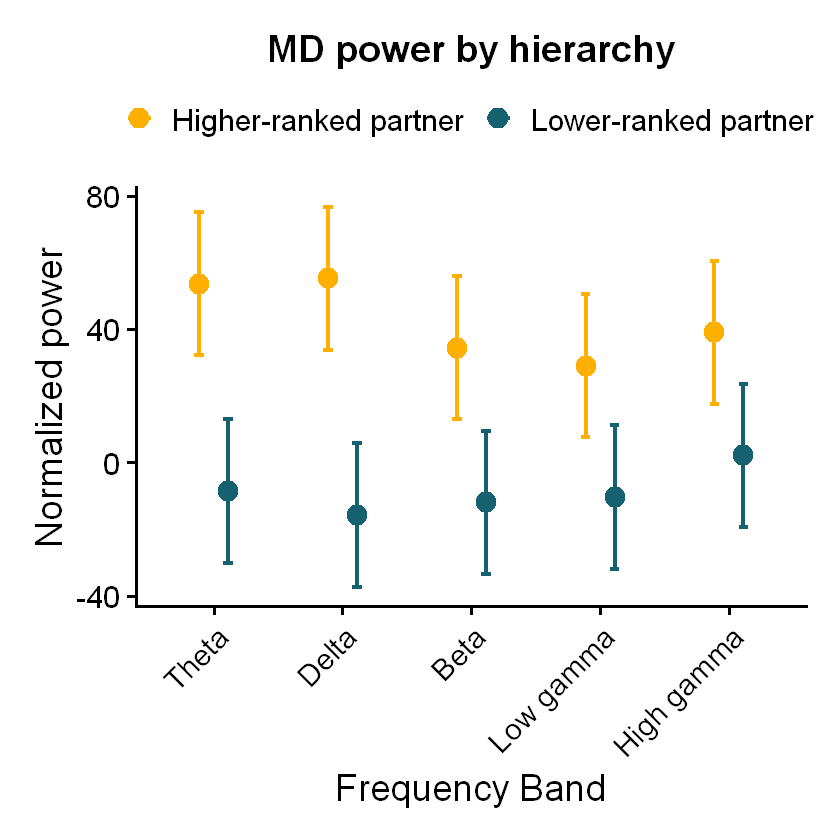


Analyzing: mPFC_MD 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."



ANOVA table for mPFC_MD :
Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank        664.8  664.80     1   35.7  2.4770    0.1243    
band               11834.4 2958.60     4 3344.2 11.0234 6.998e-09 ***
velocity_mouse1      124.1  124.08     1 2290.3  0.4623    0.4966    
event_length         549.0  549.02     1 3344.2  2.0456    0.1527    
relative_rank:band 10756.9 2689.23     4 3344.2 10.0198 4.643e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3365' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3365)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3365' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3365)' or larger];
but be warned that this may result in large computation time and memory use.



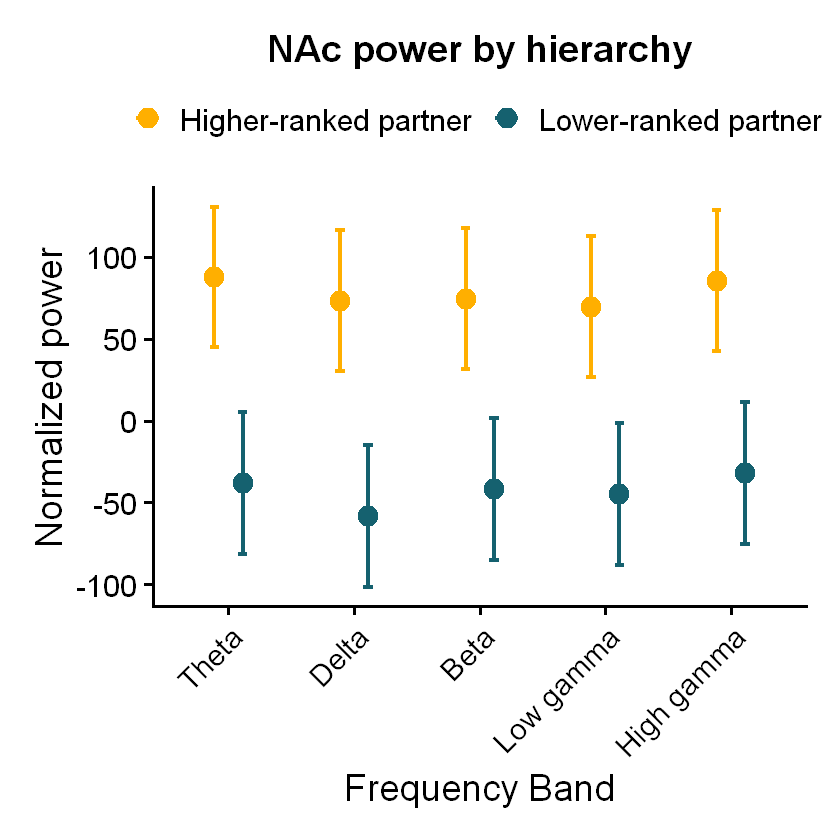


Analyzing: mPFC_NAc 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."



ANOVA table for mPFC_NAc :
Type III Analysis of Variance Table with Satterthwaite's method
                   Sum Sq Mean Sq NumDF  DenDF F value  Pr(>F)    
relative_rank         586   586.0     1   85.1  2.8868 0.09296 .  
band                32137  8034.1     4 3475.0 39.5779 < 2e-16 ***
velocity_mouse1       189   189.0     1 3260.9  0.9313 0.33460    
event_length            4     4.2     1 3481.9  0.0209 0.88503    
relative_rank:band   2207   551.9     4 3475.0  2.7186 0.02818 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3495' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3495)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3495' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3495)' or larger];
but be warned that this may result in large computation time and memory use.



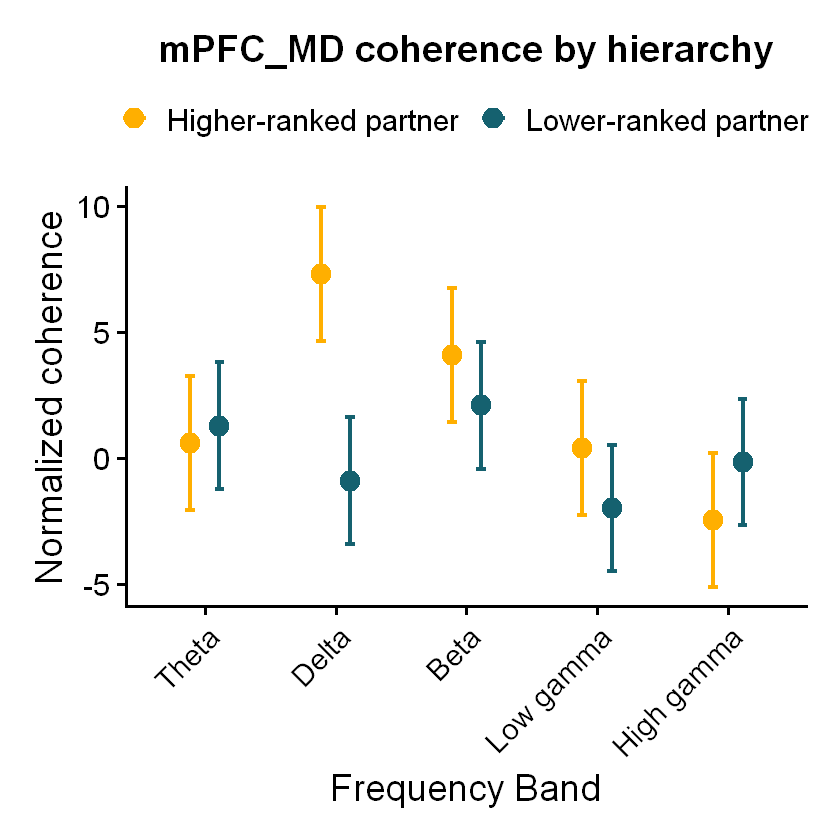


Summary of omnibus LMM results:
   region_pair             effect numerator_df denominator_df F_statistic
1           MD               band            4     3678.76312      11.984
2           MD      relative_rank            1     2303.29189     127.126
3           MD relative_rank:band            4     3678.76312      18.499
4          NAc               band            4     3808.91537      21.300
5          NAc      relative_rank            1     3738.89924     653.377
6          NAc relative_rank:band            4     3808.91537       4.255
7         mPFC               band            4     3718.20195      38.068
8         mPFC      relative_rank            1      882.83814       0.655
9         mPFC relative_rank:band            4     3718.20195       6.639
10     mPFC_MD               band            4     3344.16569      11.023
11     mPFC_MD      relative_rank            1       35.70893       2.477
12     mPFC_MD relative_rank:band            4     3344.16569      10.020
13   

region_pair,band,contrast,estimate,test_stat,p_value,p_label
<chr>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>
NAc,Delta,higher_than_subject - lower_than_subject,131.178412,23.077101,7.863632e-118,< 0.001
NAc,Theta,higher_than_subject - lower_than_subject,125.958072,22.158731,8.593864e-109,< 0.001
NAc,High gamma,higher_than_subject - lower_than_subject,117.568578,20.682839,4.944412e-95,< 0.001
NAc,Beta,higher_than_subject - lower_than_subject,116.255399,20.451822,5.787261e-93,< 0.001
NAc,Low gamma,higher_than_subject - lower_than_subject,114.057459,20.065157,1.488189e-89,< 0.001
MD,Delta,higher_than_subject - lower_than_subject,70.988554,12.934133,2.888635e-38,< 0.001
MD,Theta,higher_than_subject - lower_than_subject,62.201769,11.333178,8.988273e-30,< 0.001
MD,Beta,higher_than_subject - lower_than_subject,46.419004,8.457554,2.730430e-17,< 0.001
MD,Low gamma,higher_than_subject - lower_than_subject,39.357810,7.171003,7.445016e-13,< 0.001


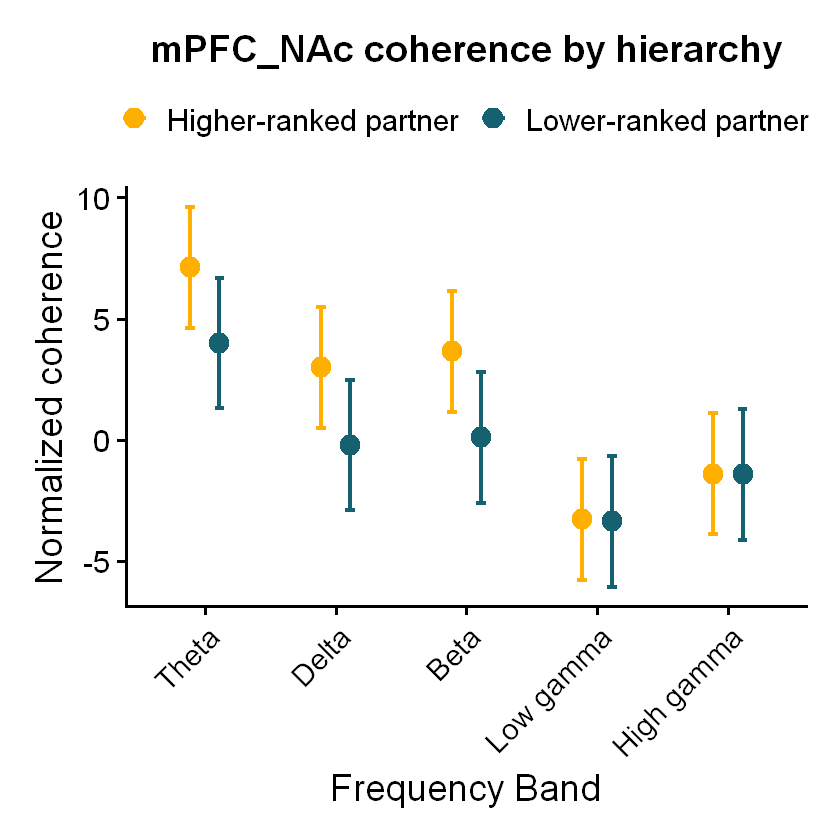

In [21]:
# --------------------------------------------------
# Focus analysis on mPFC, MD, NAc and the two
# region-pair contrasts: mPFC_MD and mPFC_NAc
# using the correct metric for each entry type:
# - power for single regions
# - coherence for region pairs
# --------------------------------------------------

if (!exists("df") || !is.data.frame(get0("df"))) {
    df <- read_csv(
        "C:/Users/sjs93/OneDrive/Documents/GitHub/diff_fam_social_memory_ephys/other_peoples_sutff/sequioa/Phase1_hab_dis_rank_GLM/lfp_kinematics_habit_dishabit_cagemate_rank.csv"
    )
}

if (!exists("coh_df") || !is.data.frame(get0("coh_df"))) {
    coh_df <- df |>
        filter(
            !is.na(value),
            !is.na(region_or_pair),
            !is.na(relative_rank),
            !is.na(band),
            !is.na(metric)
        )
}

# Use power for single regions and coherence for region pairs.
target_pairs <- c("mPFC", "MD", "NAc", "mPFC_MD", "mPFC_NAc")

plot_df <- coh_df |>
    filter(
        region_or_pair %in% target_pairs,
        relative_rank != "equal_rank"
    ) |>
    mutate(
        metric = case_when(
            region_or_pair %in% c("mPFC", "MD", "NAc") ~ "power",
            TRUE ~ "coherence"
        ),
        band = factor(
            band,
            levels = c("Theta", "Delta", "Beta", "Low gamma", "High gamma")
        ),
        relative_rank = factor(
            relative_rank,
            levels = c("higher_than_subject", "lower_than_subject")
        ),
        region_or_pair = factor(region_or_pair, levels = target_pairs)
    ) |>
    filter(metric == case_when(
        region_or_pair %in% c("mPFC", "MD", "NAc") ~ "power",
        TRUE ~ "coherence"
    ))

posthoc_results <- list()
omnibus_results <- list()

for (pair in target_pairs) {

    cat("\n=========================\n")
    cat("Analyzing:", pair, "\n")
    cat("=========================\n")

    metric_choice <- if (pair %in% c("mPFC", "MD", "NAc")) "power" else "coherence"
    y_label <- if (metric_choice == "power") "Normalized power" else "Normalized coherence"

    test_df <- plot_df |>
        filter(region_or_pair == pair, metric == metric_choice)

    if (nrow(test_df) == 0) {
        next
    }

    model <- lmer(
        value ~
            relative_rank * band +
            velocity_mouse1 +
            event_length +
            (1 | recording),
        data = test_df
    )

    # --------------------------------------------------
    # Omnibus LMM tests for main effects and interaction
    # --------------------------------------------------
    model_anova <- anova(model, type = 3)

    cat("\nANOVA table for", pair, ":\n")
    print(model_anova)

    omnibus_df <- as.data.frame(model_anova) |>
        tibble::rownames_to_column(var = "effect") |>
        filter(effect %in% c("relative_rank", "band", "relative_rank:band"))

    if ("NumDF" %in% names(omnibus_df)) {
        omnibus_df <- omnibus_df |>
            rename(
                numerator_df = NumDF,
                denominator_df = DenDF,
                F_statistic = `F value`,
                p_value = `Pr(>F)`
            )
    } else {
        omnibus_df <- omnibus_df |>
            rename(
                numerator_df = numDF,
                denominator_df = denDF,
                F_statistic = `F value`,
                p_value = `Pr(>F)`
            )
    }

    omnibus_df <- omnibus_df |>
        mutate(
            region_pair = pair
        ) |>
        select(
            region_pair,
            effect,
            numerator_df,
            denominator_df,
            F_statistic,
            p_value
        )

    omnibus_results[[pair]] <- omnibus_df

    emm <- emmeans(model, ~ relative_rank | band)

    emm_df <- as.data.frame(emm) |>
        filter(relative_rank != "equal_rank") |>
        mutate(
            region_or_pair = pair,
            relative_rank = recode(
                relative_rank,
                "higher_than_subject" = "Higher-ranked partner",
                "lower_than_subject" = "Lower-ranked partner"
            )
        )

    posthoc_out <- pairs(emm, adjust = "tukey") |>
        as.data.frame() |>
        mutate(
            region_pair = pair,
            p_value = p.value,
            sig = p_value < 0.05
        )

    if ("t.ratio" %in% names(posthoc_out)) {
        posthoc_out <- posthoc_out |> mutate(test_stat = t.ratio)
    } else if ("z.ratio" %in% names(posthoc_out)) {
        posthoc_out <- posthoc_out |> mutate(test_stat = z.ratio)
    } else {
        posthoc_out <- posthoc_out |> mutate(test_stat = NA_real_)
    }

    posthoc_results[[pair]] <- posthoc_out |>
        select(
            region_pair,
            band,
            contrast,
            estimate,
            SE,
            df,
            test_stat,
            p_value,
            sig
        )

    p <- ggplot(
        emm_df,
        aes(
            x = band,
            y = emmean,
            color = relative_rank
        )
    ) +
        geom_point(
            position = position_dodge(width = 0.45),
            size = 5
        ) +
        geom_errorbar(
            aes(
                ymin = asymp.LCL,
                ymax = asymp.UCL
            ),
            position = position_dodge(width = 0.45),
            width = 0.15,
            linewidth = 1.2
        ) +
        scale_color_manual(
            values = c(
                "Higher-ranked partner" = "#ffaf00",
                "Lower-ranked partner" = "#15616f"
            )
        ) +
        labs(
            title = paste0(pair, " ", metric_choice, " by hierarchy"),
            x = "Frequency Band",
            y = y_label,
            color = NULL
        ) +
        theme_classic(base_size = 22) +
        theme(
            plot.title = element_text(face = "bold", size = 22, hjust = 0.5),
            axis.title = element_text(size = 22),
            axis.text = element_text(size = 18, color = "black"),
            axis.text.x = element_text(angle = 45, hjust = 1),
            legend.position = "top",
            legend.text = element_text(size = 18),
            plot.margin = margin(20, 20, 20, 20)
        )

    print(p)
}

posthoc_df <- bind_rows(posthoc_results)

cat("\nSummary of omnibus LMM results:\n")
lmm_anova_summary <- bind_rows(omnibus_results) |>
    mutate(
        p_value = round(p_value, 6),
        F_statistic = round(F_statistic, 3)
    ) |>
    arrange(region_pair, effect)

print(lmm_anova_summary)

posthoc_sig_summary <- posthoc_df |>
    filter(sig) |>
    mutate(
        p_label = ifelse(
            p_value < 0.001,
            "< 0.001",
            sprintf("%.3f", p_value)
        )
    ) |>
    arrange(p_value) |>
    select(
        region_pair,
        band,
        contrast,
        estimate,
        test_stat,
        p_value,
        p_label
    )

posthoc_sig_summary

In [15]:
# --------------------------------------------------
# Inspect metric values to distinguish power rows from
# coherence rows in the dataset
# --------------------------------------------------

if (!exists("df") || !is.data.frame(get0("df"))) {
    df <- read_csv(
        "C:/Users/sjs93/OneDrive/Documents/GitHub/diff_fam_social_memory_ephys/other_peoples_sutff/sequioa/Phase1_hab_dis_rank_GLM/lfp_kinematics_habit_dishabit_cagemate_rank.csv"
    )
}

cat("Unique metric values:\n")
print(unique(df$metric))

cat("\nCounts by metric and region_or_pair:\n")
print(df |>
    count(metric, region_or_pair) |>
    arrange(metric, region_or_pair))

Unique metric values:
[1] "power"     "coherence" "granger"  

Counts by metric and region_or_pair:
# A tibble: 35 × 3
   metric    region_or_pair     n
   <chr>     <chr>          <int>
 1 coherence BLA_vHPC        4230
 2 coherence MD_BLA          4230
 3 coherence MD_vHPC         4230
 4 coherence NAc_BLA         4230
 5 coherence NAc_MD          4230
 6 coherence NAc_vHPC        4230
 7 coherence mPFC_BLA        4230
 8 coherence mPFC_MD         4230
 9 coherence mPFC_NAc        4230
10 coherence mPFC_vHPC       4230
# ℹ 25 more rows
